# HW 5 - Statistics Module
## BIOMEDE 241, Winter 2026
Please download a copy of this file via Canvas and open with Google Colaboratory, which can be found at colab.research.google.com. After finishing all of the exercises by entering all of your code, please save a completed version of this file and upload to Canvas under the assignment for this week. Please pay careful attention to how the answer should be displayed in the code (for example as a number or a plot).


Include any libraries you need here:


In [1]:
import statistics as stats
import numpy as np
import matplotlib.pyplot as plt
import math

np.random.seed(0)

%matplotlib inline

#1. Gaussian Distribution

a.	Google how to use the 'random' command in python to take draws from a Gaussian distribution. Write a function called gen_normal to generate N draws from a standard normal distribution distribution and return the generated data, mean, and standard deviation.

Generate 1,000,000 draws using your function, plot a histogram of the result, and print out the mean and standard deviation of this distribution.

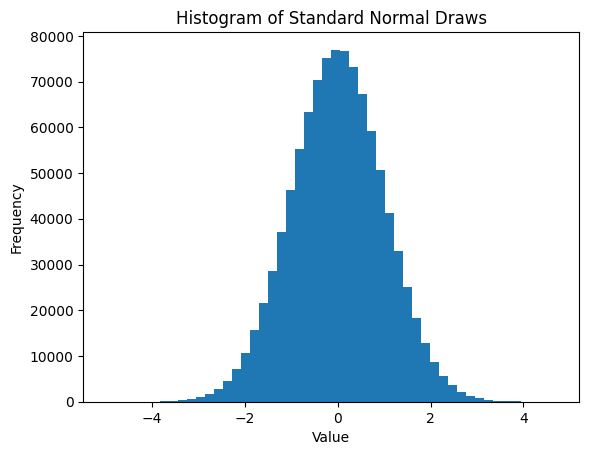

Mean: 0.0015121465155362318
Standard deviation: 0.9999213260166574


In [3]:
def gen_normal(N):
    data = np.random.normal(loc=0, scale=1, size=N)
    mean = np.mean(data)
    std = np.std(data)
    return data, mean, std

data_normal, mean_normal, std_normal = gen_normal(1_000_000)

plt.hist(data_normal, bins=50)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of Standard Normal Draws")
plt.show()

print("Mean:", mean_normal)
print("Standard deviation:", std_normal)

b. Write code to count up what proportion of the 1,000,000 datapoints fall within one standard deviation of the mean, and within 2 standard deviations of the mean. Print out how many fall within 1 and 2 std of the mean.

In [4]:
within_1_std = np.sum((data_normal >= mean_normal - std_normal) & (data_normal <= mean_normal + std_normal))
within_2_std = np.sum((data_normal >= mean_normal - 2*std_normal) & (data_normal <= mean_normal + 2*std_normal))

print("Count within 1 std of mean:", within_1_std)
print("Count within 2 std of mean:", within_2_std)

Count within 1 std of mean: 682800
Count within 2 std of mean: 954563


#2. Standard Normal Distribution and Z-scores

a. A Z-table is a list of cumulative probabilities taken from a standard normal distribution spanning by some interval from the far negative side of the Gaussian peak to the far positive side. Going from a z-score of -4 to 4 in intervals of delta, write a function create_z_table that uses the ‘norm.cdf()’ function in scipy.stats to create a Z-table, which should have 8/delta + 1 values. Store them in an array and return the values of that array. Run your function for delta=0.5 and print the values and the number of elements.

In [6]:
from scipy.stats import norm

def create_z_table(delta):
    z_vals = np.arange(-4, 4 + delta, delta)
    cdf_vals = norm.cdf(z_vals)
    return cdf_vals

z_table = create_z_table(0.5)

print("Z-table values:")
print(z_table)
print("Number of elements:", len(z_table))

Z-table values:
[3.16712418e-05 2.32629079e-04 1.34989803e-03 6.20966533e-03
 2.27501319e-02 6.68072013e-02 1.58655254e-01 3.08537539e-01
 5.00000000e-01 6.91462461e-01 8.41344746e-01 9.33192799e-01
 9.77249868e-01 9.93790335e-01 9.98650102e-01 9.99767371e-01
 9.99968329e-01]
Number of elements: 17


b. Write a function z_score to convert a Gaussian random variable to a standard normal variable by calculating the z-scored values. Imagine you have a Gaussian random variable with a mean of 7 and a standard deviation of 2. Calculate the Z-scores of the specific values 8 and 12 using your function.

In [7]:
def z_score(x, mean, std):
    return (x - mean) / std

z_8 = z_score(8, 7, 2)
z_12 = z_score(12, 7, 2)

print("Z-score of 8:", z_8)
print("Z-score of 12:", z_12)

Z-score of 8: 0.5
Z-score of 12: 2.5


c. Use the values in your generated Z-table above, calculate the probability of getting a value between 8 and 12 assuming that mean and standard deviation are the same as above.

In [8]:
prob_between = norm.cdf(z_12) - norm.cdf(z_8)
print("Probability of getting a value between 8 and 12:", prob_between)

Probability of getting a value between 8 and 12: 0.3023278734002107


d.	Repeat the same thing using norm.cdf() in scipy.stats to make sure you got the same answer.

In [9]:
prob_between = norm.cdf(z_12) - norm.cdf(z_8)
print("Probability of getting a value between 8 and 12:", prob_between)

Probability of getting a value between 8 and 12: 0.3023278734002107


#3. Central Limit Theorem

You will be generating data from a uniform distribution, a Gaussian distribution, a Poisson distribution, and an exponential distribution using ‘random.uniform’, ‘random.normal’, ‘np.random.poisson’, and ‘random.exponential’ functions in the numpy module.

a. Write a function called gen_dist that takes in a mean value and outputs a dictionary whose keys are 'Uniform', 'Gaussian', 'Poisson' and 'Exponential' and whose values correspond to the generated data from each of those distributions. Run your function for a mean value of 5 and save the results in a variable.

In [10]:
def gen_dist(mean, N):
    return {
        'Uniform': np.random.uniform(0, 2*mean, N),
        'Gaussian': np.random.normal(loc=mean, scale=1, size=N),
        'Poisson': np.random.poisson(lam=mean, size=N),
        'Exponential': np.random.exponential(scale=mean, size=N)
    }

dist_data = gen_dist(5, 1000)

b. Using the dictionary of values from above, plot each distribution of data as a histogram, using 4 subplots (one for each distribution). Use a for loop and iterate through each key and value pair of the dictionary to make the final plot. Include the average value of each distribution in the title, rounded to 3 decimals, along with the name of the distribution found in the key.

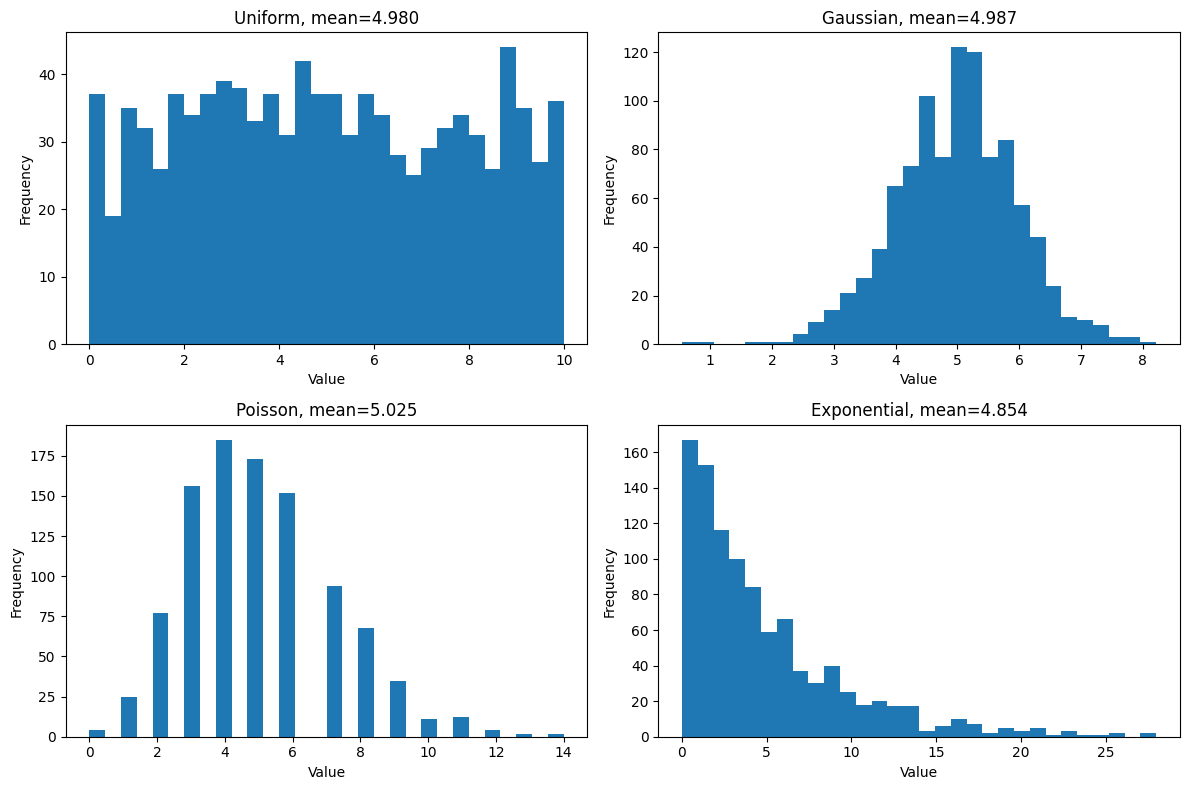

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, (name, values) in zip(axes, dist_data.items()):
    ax.hist(values, bins=30)
    ax.set_title(f"{name}, mean={np.mean(values):.3f}")
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

c. Now make a new function mean_dist that, instead of generating data from a distribution, takes M draws from a distribution and calculates their mean, and does so N times. It will return this N data for each distribution that is the distribution of mean values for each set of M draws. Use a dictionary like you did in gen_dist. Plot the histograms of results (using 4 subplots) from this function if you use M=2 draws for N=1000. Include the average value of each (mean) distribution in the title, rounded to 3 decimals, along with the name of the distribution.


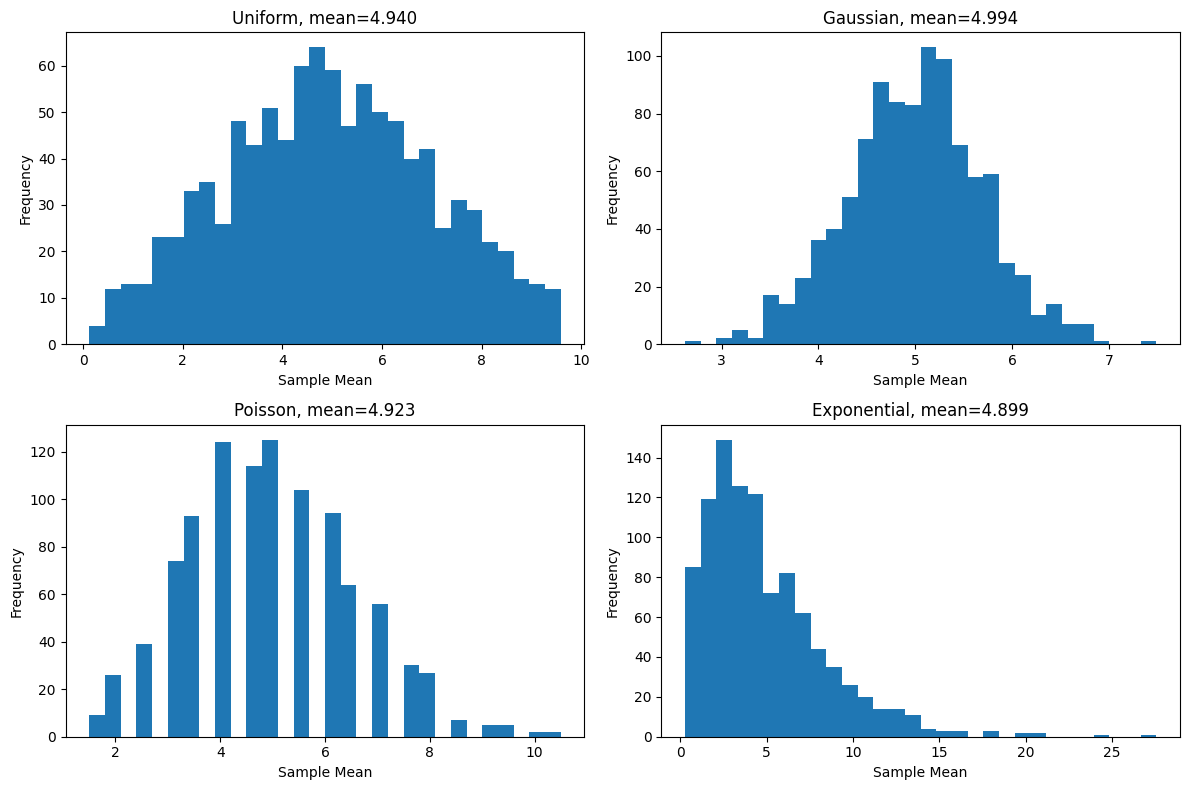

In [12]:
def mean_dist(mean, N, M):
    results = {'Uniform': [], 'Gaussian': [], 'Poisson': [], 'Exponential': []}
    
    for _ in range(N):
        results['Uniform'].append(np.mean(np.random.uniform(0, 2*mean, M)))
        results['Gaussian'].append(np.mean(np.random.normal(loc=mean, scale=1, size=M)))
        results['Poisson'].append(np.mean(np.random.poisson(lam=mean, size=M)))
        results['Exponential'].append(np.mean(np.random.exponential(scale=mean, size=M)))
    
    for key in results:
        results[key] = np.array(results[key])
    
    return results

mean_data_M2 = mean_dist(5, 1000, 2)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, (name, values) in zip(axes, mean_data_M2.items()):
    ax.hist(values, bins=30)
    ax.set_title(f"{name}, mean={np.mean(values):.3f}")
    ax.set_xlabel("Sample Mean")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

d. Do the same for M=5 draws and plot the results as above in 4 subplots.

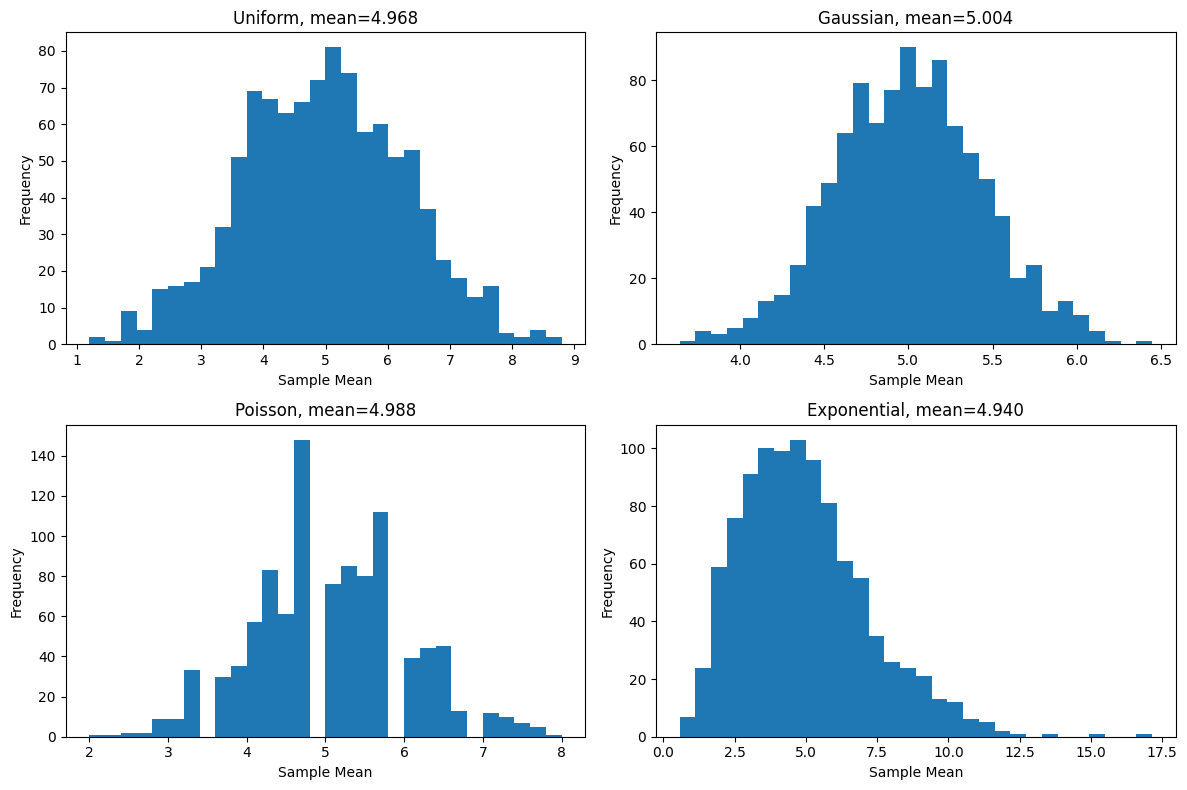

In [13]:
mean_data_M5 = mean_dist(5, 1000, 5)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, (name, values) in zip(axes, mean_data_M5.items()):
    ax.hist(values, bins=30)
    ax.set_title(f"{name}, mean={np.mean(values):.3f}")
    ax.set_xlabel("Sample Mean")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

e.	Repeat this process taking the mean of 10,000 draws a total of 1000 times and plot 4 histograms.

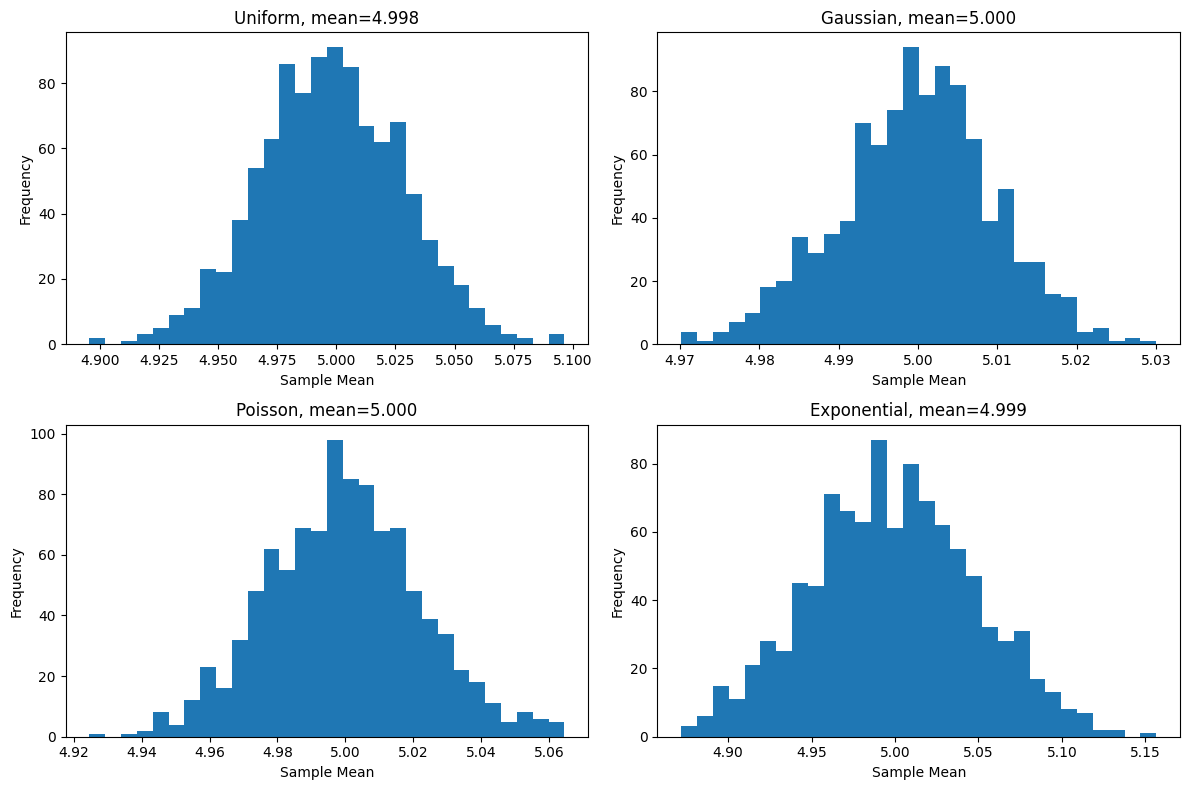

In [14]:
mean_data_M10000 = mean_dist(5, 1000, 10000)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, (name, values) in zip(axes, mean_data_M10000.items()):
    ax.hist(values, bins=30)
    ax.set_title(f"{name}, mean={np.mean(values):.3f}")
    ax.set_xlabel("Sample Mean")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

f.	Compare the plots using the fewest number of draws to the plots using the most number of draws and write what you observe. What is the mean of every distribution? What distribution do all plots in e. resemble?

>Answer here

 As the number of draws increases, the distributions of the sample means become narrower and more bell-shaped. The mean of every distribution stays approximately equal to 5. In part e, all four histograms resemble a Gaussian (normal) distribution.

g. Why are these distributions getting narrower and what does this imply for sampling a large number of repeated measurements from the same distribution?



>Answer here

These distributions get narrower because the variability of the sample mean decreases as more draws are averaged together. This implies that sampling a large number of repeated measurements from the same distribution gives a more precise estimate of the true mean.

#4. Sampling and Standard Error of the Mean

a.	In a million parallel universes, you the scientist are trying to do the same experiment to measure the mean of random variable X. In all of these universes, the underlying distribution of X is Gaussian, with a mean of 40, and a standard deviation of 5. The experiment consists of measuring the value of X a total of 100 times. Simulate the million mean values that you get from the experiment in the million parallel universes and plot a histogram.

Hint: You can generate the data from all million universes with one numpy.random.normal() command.

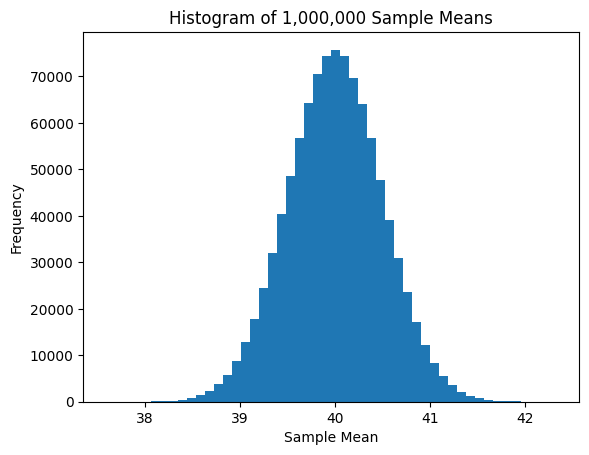

In [15]:
all_data = np.random.normal(loc=40, scale=5, size=(1_000_000, 100))
universe_means = np.mean(all_data, axis=1)

plt.hist(universe_means, bins=50)
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")
plt.title("Histogram of 1,000,000 Sample Means")
plt.show()

b.	Calculate the theoretical standard error of the mean from the equation. Make sure to use the correct ‘n’.

In [16]:
sem_theoretical = 5 / np.sqrt(100)
print("Theoretical standard error of the mean:", sem_theoretical)

Theoretical standard error of the mean: 0.5


c.	Count up the percentage of parallel universes in which the measured mean value was within one standard error of the mean. Why does it have this value?

In [17]:
within_one_sem = np.sum((universe_means >= 40 - sem_theoretical) & (universe_means <= 40 + sem_theoretical))
percent_within_one_sem = 100 * within_one_sem / len(universe_means)

print("Percentage within one standard error:", percent_within_one_sem)

Percentage within one standard error: 68.3071


d. Take the standard deviations associated with these 1 million experiments. Make sure you have 1 million values rather than 100. Then, find the mean of these standard deviations.

In [18]:
universe_stds = np.std(all_data, axis=1, ddof=1)
print("Mean of the 1,000,000 standard deviations:", np.mean(universe_stds))

Mean of the 1,000,000 standard deviations: 4.9870138699927775


e.	With 1 million standard deviations, why is their mean slightly below the real value of sigma? What is the most accurate way of estimating sigma from the standard deviation of the results and what do you get?

In [19]:
std_of_means = np.std(universe_means, ddof=1)
sigma_estimate = std_of_means * np.sqrt(100)

print("Estimated sigma from the standard deviation of the sample means:", sigma_estimate)

Estimated sigma from the standard deviation of the sample means: 4.997542372857674


f. Imagine scientist you in all 1 million universes made the same mistake in file labeling and actually included the same 50 data points two times. These are now not independent measurements. You can use np.append to make this dataset. Determine what percentage of parallel universe scientists get an answer within what they think is one standard error of the mean. Compare this to what it should be without the mistake.

In [20]:
first_50 = all_data[:, :50]
duplicated_data = np.append(first_50, first_50, axis=1)

duplicated_means = np.mean(duplicated_data, axis=1)
duplicated_stds = np.std(duplicated_data, axis=1, ddof=1)
duplicated_sem = duplicated_stds / np.sqrt(100)

within_bad_sem = np.sum((duplicated_means >= 40 - duplicated_sem) & (duplicated_means <= 40 + duplicated_sem))
percent_within_bad_sem = 100 * within_bad_sem / len(duplicated_means)

print("Percentage within what they think is one SEM:", percent_within_bad_sem)
print("Percentage within one SEM without the mistake:", percent_within_one_sem)

Percentage within what they think is one SEM: 51.5137
Percentage within one SEM without the mistake: 68.3071


g.	Why is this a problem in terms of the experimenters' confidence in their mean?

This is a problem because the experimenters think they have 100 independent measurements, but they actually repeated the same 50 data points twice. That makes the estimated standard error too small, so they become too confident in their estimate of the mean.

h.	How is this related to independent measurements? (in terms of standard error of mean)

This is related to independent measurements because the standard error of the mean assumes that all samples are independent. When measurements are repeated or dependent, the effective sample size is smaller than assumed, so the standard error is underestimated.